In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict, Optional
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from datasets import load_dataset

/Users/alyssagardiner/src/sae_trainer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
root = Path.cwd().resolve()
root = root.parent
sys.path.insert(0, str(root))

from sae_trainer.dataset_utils import make_collate_fn, TextDataset, get_data_loaders
from sae_trainer.train_utils import train_sae
from sae_trainer.eval_utils import evaluate_sae, visualize_sae
from sae_trainer.model_utils import SparseAutoencoder

In [8]:
class ActivationCollector:
    """
    Collects activations from selected GPT-2 layers:
      - residual_out: output of decoder layer (hidden_states)
      - mlp_down_out: output of layer.mlp.c_proj (down projection)
    """
    def __init__(
        self,
        model: torch.nn.Module,
        layer_ids: List[int],
        capture_residual: bool = True,
        capture_mlp_down: bool = False,
        to_cpu: bool = True,
        dtype: torch.dtype = torch.float32,
    ):
        self.model = model
        self.layer_ids = layer_ids
        self.capture_residual = capture_residual
        self.capture_mlp_down = capture_mlp_down
        self.to_cpu = to_cpu
        self.dtype = dtype

        self.hooks = []
        self.buffer: Dict[str, Dict[int, torch.Tensor]] = {
            "residual_out": {},
            "mlp_down_out": {},
        }

    def _clear_batch_buffer(self):
        self.buffer["residual_out"].clear()
        self.buffer["mlp_down_out"].clear()

    @staticmethod
    def _hidden_from_output(output):
        # Some HF modules return tuple; hidden_states is first item
        return output[0] if isinstance(output, tuple) else output

    def _make_block_hook(self, layer_idx: int):
        def hook(module, inputs, output):
            hs = self._hidden_from_output(output)
            t = hs.detach().to(self.dtype)
            if self.to_cpu:
                t = t.cpu()
            self.buffer["residual_out"][layer_idx] = t
        return hook

    def _make_mlp_down_hook(self, layer_idx: int):
        def hook(module, inputs, output):
            t = output.detach().to(self.dtype)
            if self.to_cpu:
                t = t.cpu()
            self.buffer["mlp_down_out"][layer_idx] = t
        return hook

    def register(self):
        self.remove()
        for i in self.layer_ids:
            layer = self.model.transformer.h[i]  # GPT-2: transformer.h[i]
            if self.capture_residual:
                self.hooks.append(layer.register_forward_hook(self._make_block_hook(i)))
            if self.capture_mlp_down:
                self.hooks.append(layer.mlp.c_proj.register_forward_hook(self._make_mlp_down_hook(i)))

    def remove(self):
        for h in self.hooks:
            h.remove()
        self.hooks = []

    def collect_batch(self, model_inputs: Dict[str, torch.Tensor], model: Optional[torch.nn.Module] = None):
        """
        Runs one forward pass and returns flattened activations per layer:
          out[name][layer] -> [batch*seq, d_model]
        """
        if model is None:
            model = self.model

        self._clear_batch_buffer()
        with torch.no_grad():
            _ = model(**model_inputs)

        out = {"residual_out": {}, "mlp_down_out": {}}
        for name in out.keys():
            for layer_idx, x in self.buffer[name].items():
                # [B, S, D] -> [B*S, D]
                out[name][layer_idx] = x.reshape(-1, x.shape[-1])
        return out


In [4]:
# --- Setup model/tokenizer ---
device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "gpt2"  # GPT-2 small: 12 layers, d_model=768

tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
model.eval()


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2SdpaAttention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [9]:
# --- Example text corpus ---
#texts = [
#    "The Eiffel Tower is in Paris.",
#    "A sparse autoencoder can discover interpretable features.",
#    "Neural networks represent concepts across many layers.",
#    "Attention heads may specialize in different linguistic patterns.",
#    "Residual stream activations are useful for mechanistic interpretability.",
#] * 200  # repeat just for demo

#dataset = TextDataset(texts)
texts = []
ds = load_dataset("wikitext", "wikitext-103-raw-v1", split="train", streaming=True)

#ds = ds.shuffle(seed=42)
#ds = ds.with_format("torch")
for row in ds:
    texts.append(row["text"])
dataset = TextDataset(texts)
loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=False,
    collate_fn=make_collate_fn(tokenizer, max_length=128),
)

In [10]:
# --- Register collector ---
# GPT-2 small has 12 layers (0-11); sample early, mid, late, and final
target_layers = [3, 6, 9, 11]
collector = ActivationCollector(
    model=model,
    layer_ids=target_layers,
    capture_residual=True,
    capture_mlp_down=False,   # set True if you want both
    to_cpu=True,
    dtype=torch.float32,
)
collector.register()


In [11]:
# --- Dataloader loop to accumulate activations ---
# Stores per-layer chunks, then concatenates at end.
accum = {"residual_out": {i: [] for i in target_layers},
         "mlp_down_out": {i: [] for i in target_layers}}

max_batches = 50  # increase for more data
for step, batch in enumerate(loader):
    if step >= max_batches:
        break

    batch = {k: v.to(device) for k, v in batch.items()}
    acts = collector.collect_batch(batch)

    # Optional: remove pad tokens before append
    # (for now we keep all tokens; filtering can be done later)

    for name in ["residual_out", "mlp_down_out"]:
        for i, x in acts[name].items():
            accum[name][i].append(x)

# concat
for name in ["residual_out", "mlp_down_out"]:
    for i in target_layers:
        if len(accum[name][i]) > 0:
            accum[name][i] = torch.cat(accum[name][i], dim=0)
        else:
            accum[name][i] = None

collector.remove()

for i in target_layers:
    x = accum["residual_out"][i]
    print(f"Layer {i} residual:", None if x is None else tuple(x.shape))

Layer 3 residual: (36152, 768)
Layer 6 residual: (36152, 768)
Layer 9 residual: (36152, 768)
Layer 11 residual: (36152, 768)


In [9]:
# Things to try:

# Decoder column unit norm
# Top-k forward (k~16-32)
# KL to target neuron firing rate

In [15]:
# 0.005 - 0.05
mass_frac_threshold=0.002

# Working combos:
# expansion=8, mass_frac_threshold=0.001
# expansion=16, mass_frac_threshold=0.0005

In [16]:
def training_wrapper(accum, layer_idx, device, mass_frac_threshold, save_filename=None):

    train_loader, val_loader, d_in = get_data_loaders(accum, layer_idx)
    # ---- Model + optimizer ----
    expansion = 8               # 4-16 are common starting points
    d_latent = d_in * expansion # d_in = 3584, so this should be in ~[14k, 60k] (14336-57344)

    sae = SparseAutoencoder(d_in=d_in, d_latent=d_latent).to(device)
    opt = torch.optim.AdamW(sae.parameters(), lr=3e-4, weight_decay=1e-4)

    # Sparsity strength: tune this. Start small.
    lambda_l1 = 1e-2

    # Optional: LR scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=20)

    sae, history = train_sae(
        sae, 
        train_loader, 
        val_loader, 
        opt, 
        scheduler, 
        device, 
        lambda_l1=lambda_l1, 
        mass_frac_threshold=mass_frac_threshold,
        lambda_kl=1e-3,           # tune in log space, e.g. 1e-4 … 1e-2
        target_firing_rate=0.02,  # desired ~soft firing mass per latent
        )

    if save_filename:
        # ---- Save checkpoint ----
        ckpt = {
            "model_state": sae.state_dict(),
            "d_in": d_in,
            "d_latent": d_latent,
            "lambda_l1": lambda_l1,
            "history": history,
        }
        torch.save(ckpt, save_filename)
        print(f"Saved: {save_filename}")

    return sae, history, train_loader, val_loader

Epoch 01 | train loss 51.691131 (recon 51.683478, l1 0.646044, kl 1.192756 / 1.036417) | val loss 3.684347 (recon 3.677550, l1 0.576119) | val active 0.9
Epoch 02 | train loss 2.860896 (recon 2.854596, l1 0.533788, kl 0.961883 / 0.901688) | val loss 1.572633 (recon 1.566615, l1 0.511699) | val active 8.7
Epoch 03 | train loss 0.987608 (recon 0.981713, l1 0.499344, kl 0.900879 / 0.894252) | val loss 0.706459 (recon 0.700547, l1 0.501758) | val active 10.9
Epoch 04 | train loss 0.570140 (recon 0.564262, l1 0.497518, kl 0.903629 / 0.900360) | val loss 0.449640 (recon 0.443722, l1 0.501752) | val active 11.6
Epoch 05 | train loss 0.377772 (recon 0.371868, l1 0.499450, kl 0.909396 / 0.908182) | val loss 0.324281 (recon 0.318343, l1 0.502974) | val active 13.0
Epoch 06 | train loss 0.300589 (recon 0.294687, l1 0.498369, kl 0.918450 / 0.914982) | val loss 0.315737 (recon 0.309776, l1 0.504664) | val active 15.2
Epoch 07 | train loss 0.237247 (recon 0.231275, l1 0.504788, kl 0.924056 / 0.92068

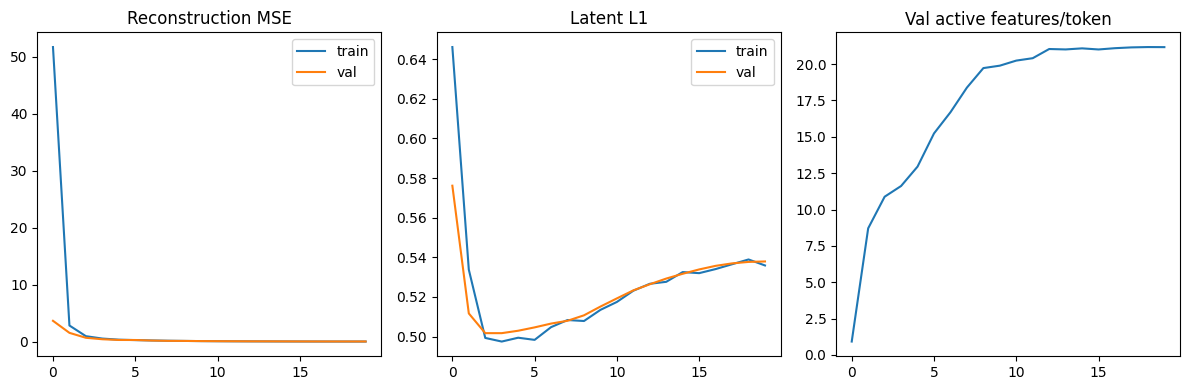

Saved: sae_gpt2_layer3.pt


In [17]:
sae_3, history_3, train_loader_3, _ = training_wrapper(accum, 3, device, mass_frac_threshold, save_filename='sae_gpt2_layer3.pt')


Epoch 01 | train loss 64.806440 (recon 64.796873, l1 0.840809, kl 1.159707 / 0.979604) | val loss 4.637121 (recon 4.628743, l1 0.739820) | val active 2.2
Epoch 02 | train loss 4.298035 (recon 4.290414, l1 0.673774, kl 0.883214 / 0.814413) | val loss 2.435944 (recon 2.428747, l1 0.638294) | val active 11.4
Epoch 03 | train loss 1.710125 (recon 1.703032, l1 0.628139, kl 0.811833 / 0.803449) | val loss 1.141107 (recon 1.134127, l1 0.617683) | val active 17.3
Epoch 04 | train loss 1.047910 (recon 1.040897, l1 0.619717, kl 0.815345 / 0.816544) | val loss 0.818591 (recon 0.811585, l1 0.619015) | val active 19.5
Epoch 05 | train loss 0.682761 (recon 0.675713, l1 0.621906, kl 0.828850 / 0.832158) | val loss 0.551569 (recon 0.544501, l1 0.623598) | val active 22.4
Epoch 06 | train loss 0.501606 (recon 0.494436, l1 0.632215, kl 0.846930 / 0.852287) | val loss 0.461954 (recon 0.454753, l1 0.634852) | val active 22.1
Epoch 07 | train loss 0.393258 (recon 0.385958, l1 0.643350, kl 0.866525 / 0.8668

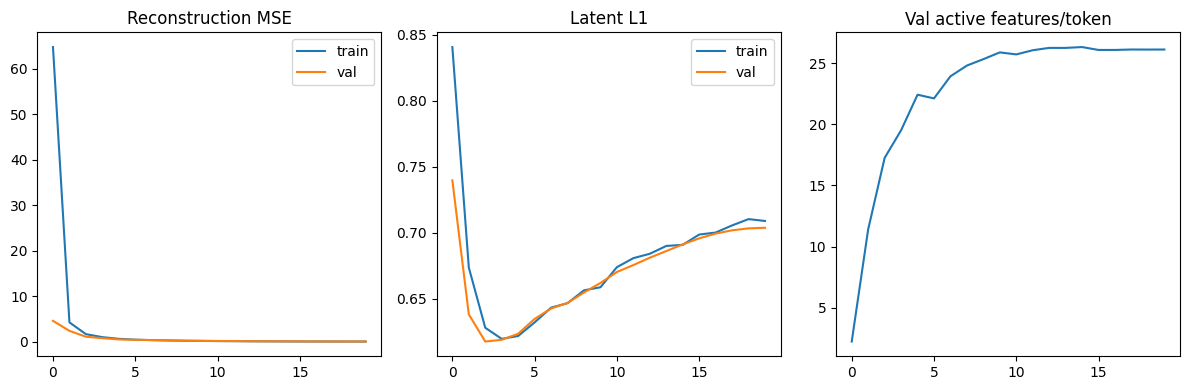

Saved: sae_gpt2_layer6.pt


In [18]:
sae_6, history_6, train_loader_6, _ = training_wrapper(accum, 6, device, mass_frac_threshold, save_filename='sae_gpt2_layer6.pt')


Epoch 01 | train loss 87.993530 (recon 87.978843, l1 1.347991, kl 1.208644 / 1.032660) | val loss 8.782041 (recon 8.769229, l1 1.177879) | val active 1.7
Epoch 02 | train loss 7.557182 (recon 7.545635, l1 1.061998, kl 0.927392 / 0.858379) | val loss 4.947215 (recon 4.936265, l1 1.009106) | val active 8.8
Epoch 03 | train loss 3.852784 (recon 3.842263, l1 0.967979, kl 0.840436 / 0.829911) | val loss 2.927265 (recon 2.916833, l1 0.960187) | val active 11.8
Epoch 04 | train loss 2.480589 (recon 2.470266, l1 0.948998, kl 0.832855 / 0.838922) | val loss 1.962553 (recon 1.952227, l1 0.948627) | val active 14.2
Epoch 05 | train loss 1.687707 (recon 1.677300, l1 0.955286, kl 0.854602 / 0.867656) | val loss 1.438184 (recon 1.427706, l1 0.961017) | val active 15.3
Epoch 06 | train loss 1.178860 (recon 1.168237, l1 0.973767, kl 0.884936 / 0.899447) | val loss 1.064215 (recon 1.053493, l1 0.982237) | val active 16.2
Epoch 07 | train loss 0.937776 (recon 0.926907, l1 0.995356, kl 0.915246 / 0.92327

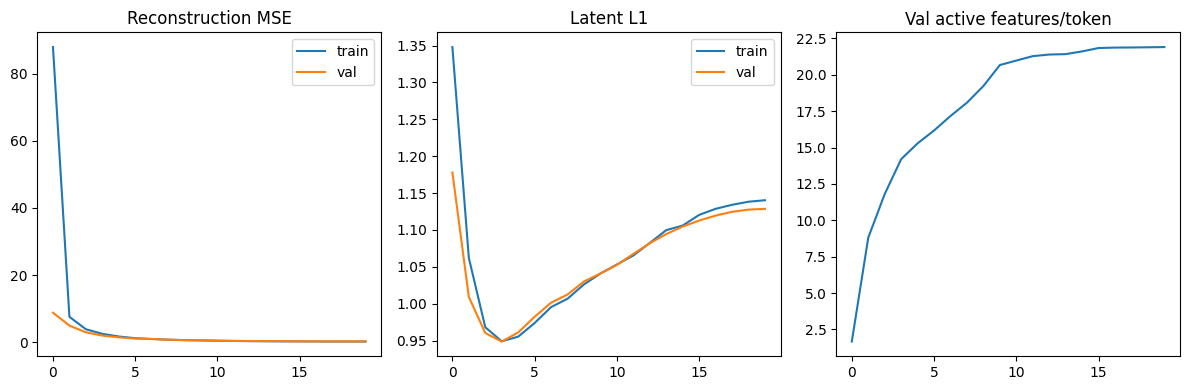

Saved: sae_gpt2_layer9.pt


In [19]:
sae_9, history_9, train_loader_9, _ = training_wrapper(accum, 9, device, mass_frac_threshold, save_filename='sae_gpt2_layer9.pt')


Epoch 01 | train loss 115.637859 (recon 115.607575, l1 2.888556, kl 1.397148 / 1.219450) | val loss 20.684572 (recon 20.657761, l1 2.559304) | val active 0.7
Epoch 02 | train loss 14.935525 (recon 14.910426, l1 2.393731, kl 1.161563 / 1.114244) | val loss 10.016425 (recon 9.992149, l1 2.316229) | val active 2.3
Epoch 03 | train loss 8.438987 (recon 8.415671, l1 2.221763, kl 1.098682 / 1.090905) | val loss 6.589697 (recon 6.566494, l1 2.211244) | val active 4.5
Epoch 04 | train loss 5.670196 (recon 5.647519, l1 2.158223, kl 1.094424 / 1.103961) | val loss 4.714159 (recon 4.691259, l1 2.179623) | val active 5.6
Epoch 05 | train loss 4.057933 (recon 4.035337, l1 2.147763, kl 1.118261 / 1.134902) | val loss 3.633183 (recon 3.610197, l1 2.185089) | val active 6.1
Epoch 06 | train loss 3.087404 (recon 3.064686, l1 2.157240, kl 1.145732 / 1.156901) | val loss 2.792079 (recon 2.768981, l1 2.194103) | val active 7.3
Epoch 07 | train loss 2.440529 (recon 2.417649, l1 2.171089, kl 1.168573 / 1.17

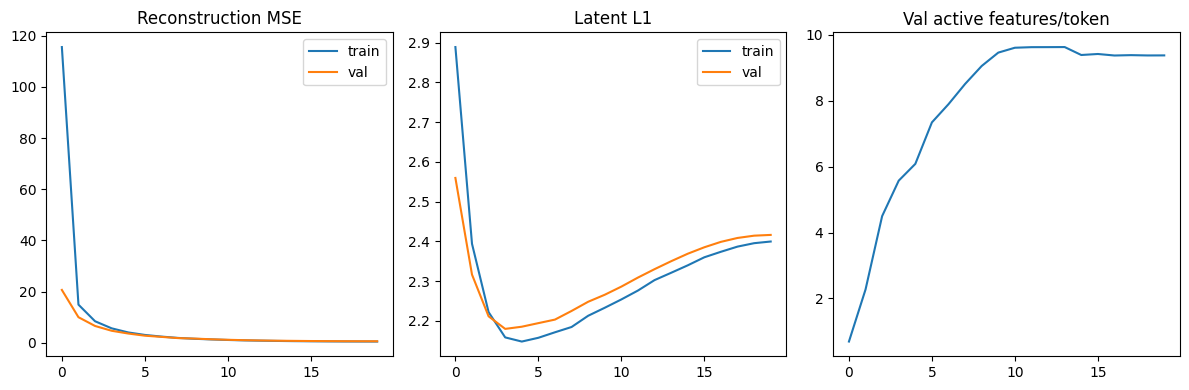

Saved: sae_gpt2_layer11.pt


In [20]:
sae_11, history_11, train_loader_11, _ = training_wrapper(accum, 11, device, mass_frac_threshold, save_filename='sae_gpt2_layer11.pt')


In [21]:
history_3['train_l1']


[0.6460441909730434,
 0.53378751501441,
 0.49934387765824795,
 0.49751768447458744,
 0.49944958090782166,
 0.4983687847852707,
 0.5047878082841635,
 0.5083717331290245,
 0.5078801810741425,
 0.5134956277906895,
 0.51749805547297,
 0.5231637451797724,
 0.5266485642641783,
 0.5276455953717232,
 0.5325575787574053,
 0.5320179667323828,
 0.5340755637735128,
 0.5365049950778484,
 0.5389181692153215,
 0.5358956251293421]

In [22]:
metrics_3 = evaluate_sae(sae_3, train_loader_3, device, mass_frac_threshold=mass_frac_threshold, show_metrics=True)


=== SAE Metrics ===
                             mse: 0.039708
              explained_variance: 0.999629
                   avg_l1_latent: 0.537240
   avg_active_features_per_token: 21.009003
               dead_feature_rate: 0.969401
                   usage_entropy: 4.486873
                usage_perplexity: 88.843212


In [23]:
metrics_6 = evaluate_sae(sae_6, train_loader_6, device, mass_frac_threshold=mass_frac_threshold, show_metrics=True)


=== SAE Metrics ===
                             mse: 0.075224
              explained_variance: 0.999459
                   avg_l1_latent: 0.712058
   avg_active_features_per_token: 26.127258
               dead_feature_rate: 0.972656
                   usage_entropy: 4.539611
                usage_perplexity: 93.654393


In [24]:
metrics_9 = evaluate_sae(sae_9, train_loader_9, device, mass_frac_threshold=mass_frac_threshold, show_metrics=True)


=== SAE Metrics ===
                             mse: 0.169031
              explained_variance: 0.999015
                   avg_l1_latent: 1.138491
   avg_active_features_per_token: 21.951141
               dead_feature_rate: 0.978516
                   usage_entropy: 4.349341
                usage_perplexity: 77.427452


In [25]:
metrics_11 = evaluate_sae(sae_11, train_loader_11, device, mass_frac_threshold=mass_frac_threshold, show_metrics=True)


=== SAE Metrics ===
                             mse: 0.471576
              explained_variance: 0.998515
                   avg_l1_latent: 2.397497
   avg_active_features_per_token: 9.455750
               dead_feature_rate: 0.981771
                   usage_entropy: 3.442108
                usage_perplexity: 31.252782


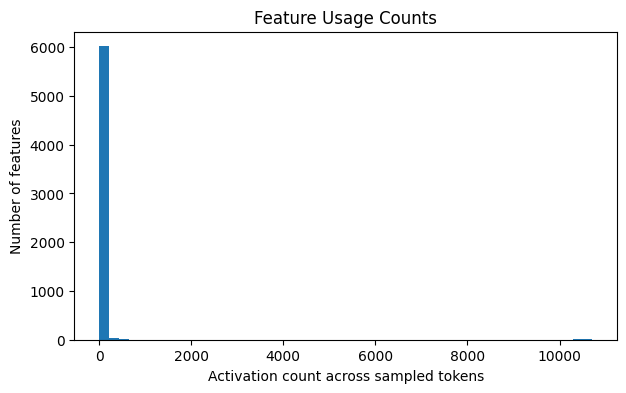

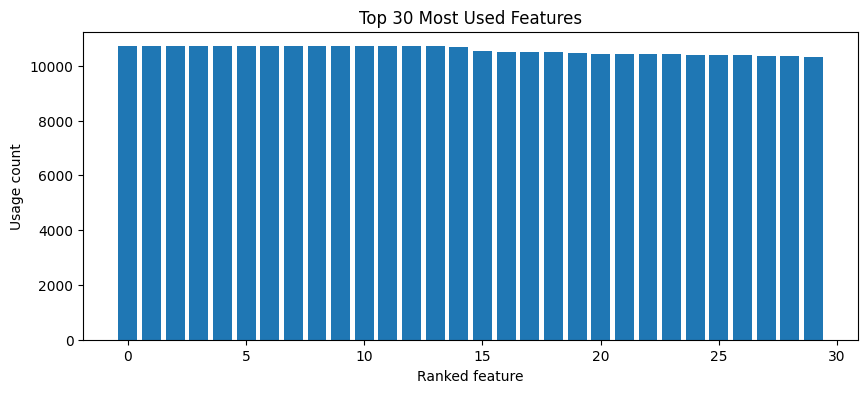

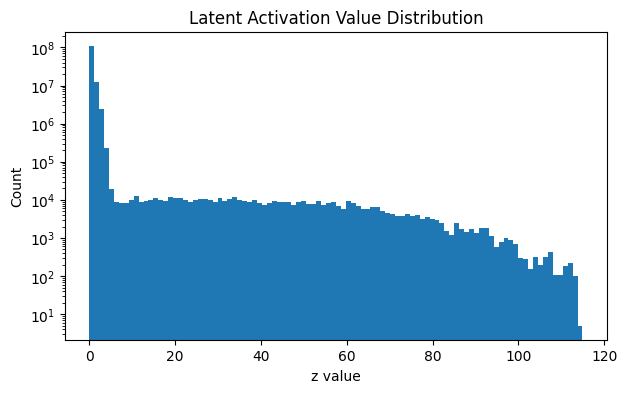

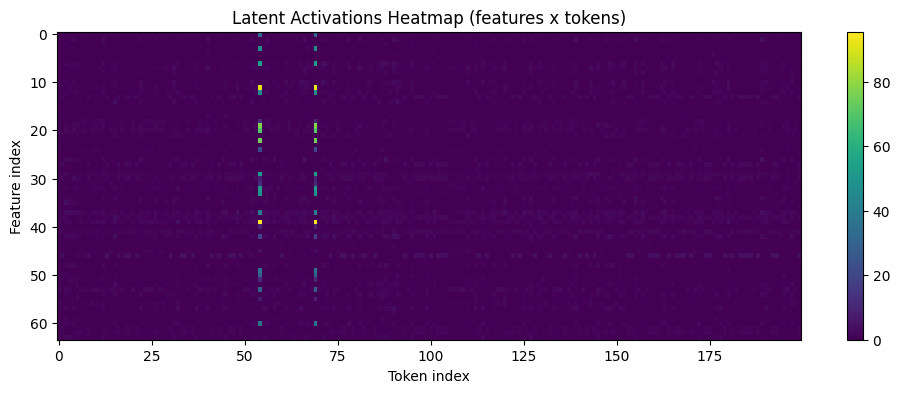

UMAP not installed. `pip install umap-learn` to enable latent-space plot.


In [26]:
visualize_sae(metrics_3)


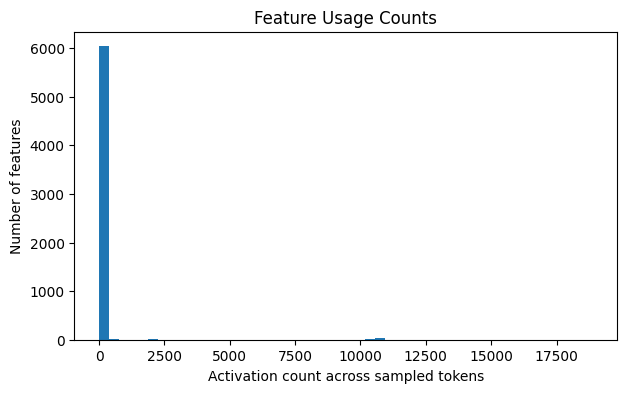

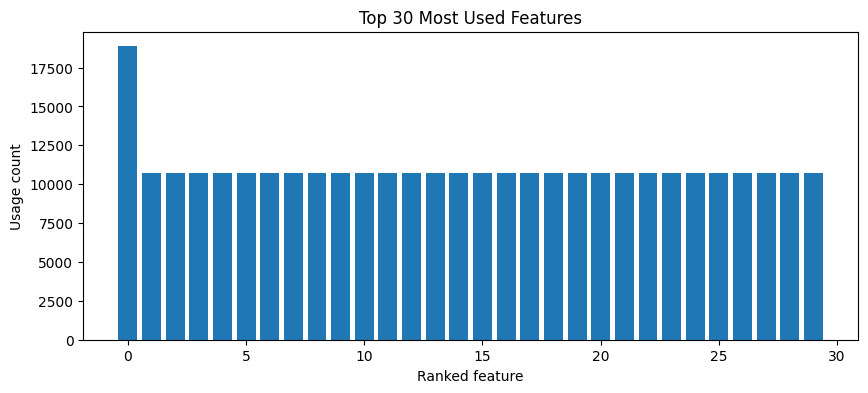

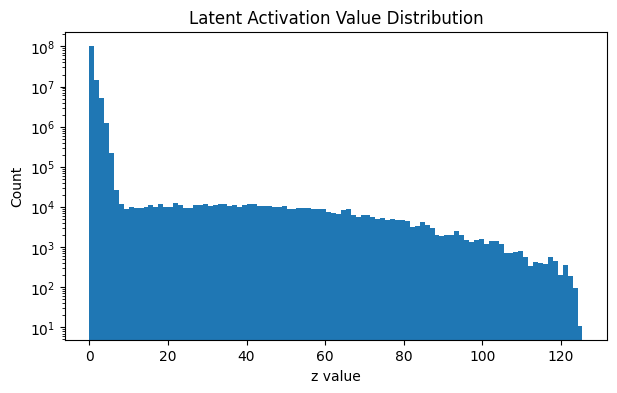

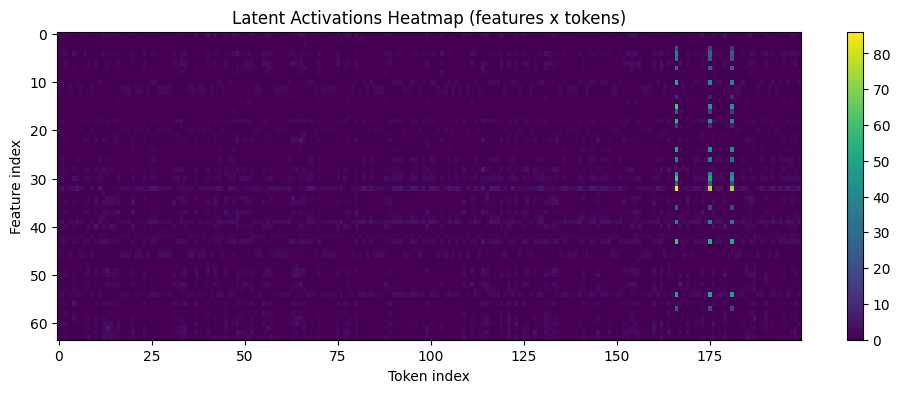

UMAP not installed. `pip install umap-learn` to enable latent-space plot.


In [27]:
visualize_sae(metrics_6)


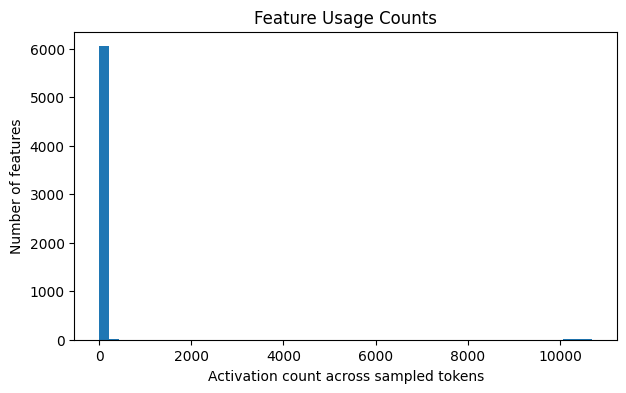

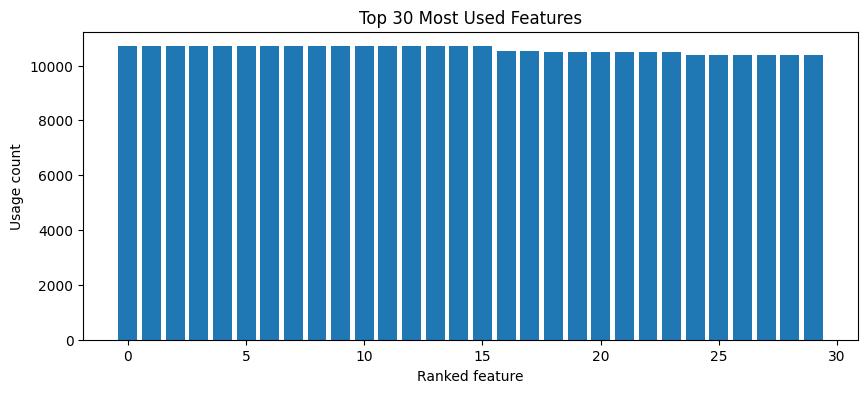

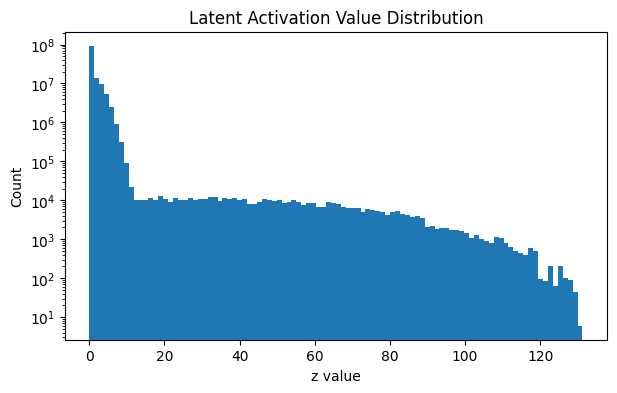

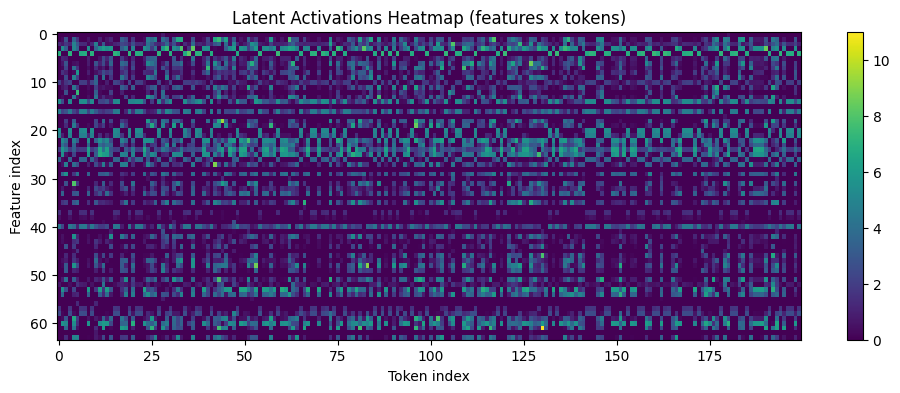

UMAP not installed. `pip install umap-learn` to enable latent-space plot.


In [28]:
visualize_sae(metrics_9)


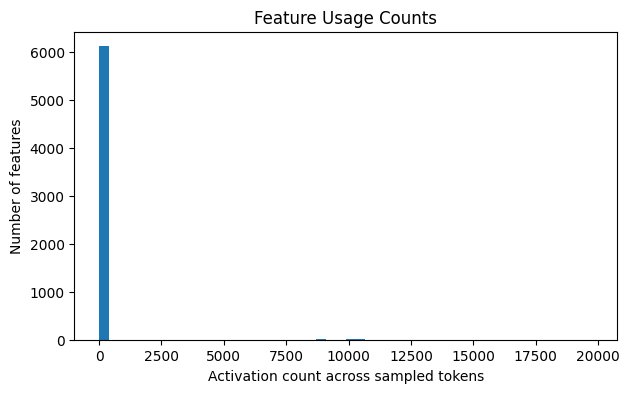

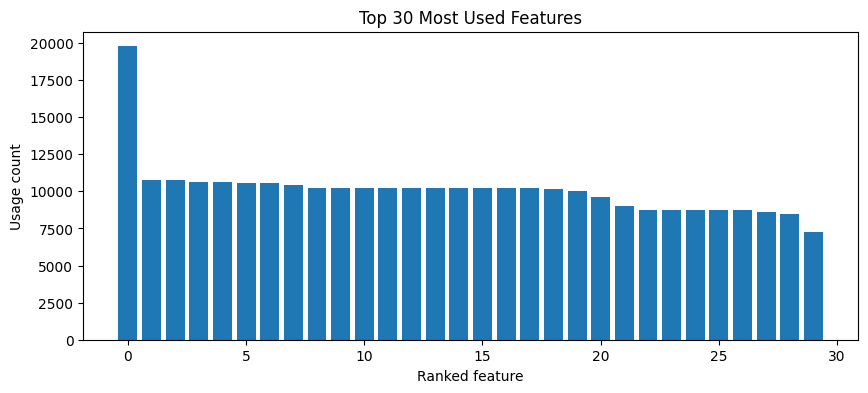

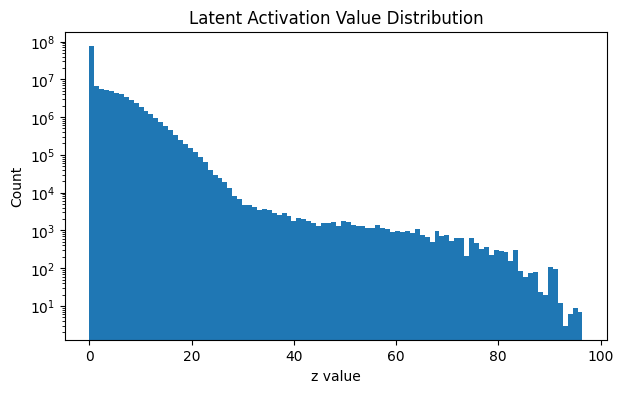

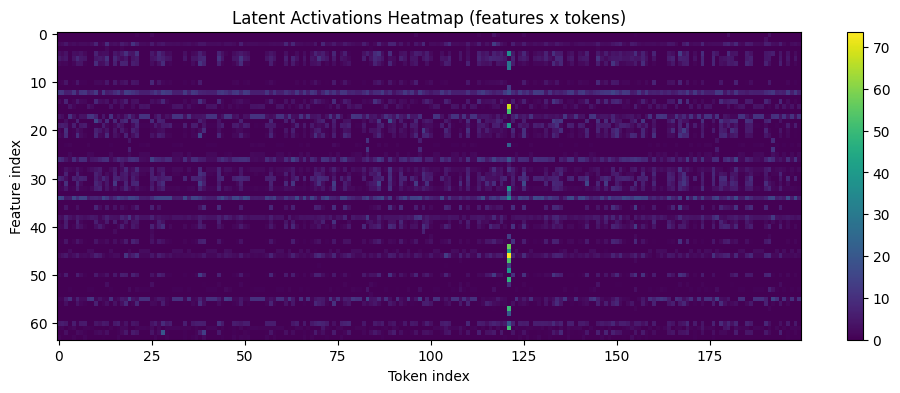

UMAP not installed. `pip install umap-learn` to enable latent-space plot.


In [29]:
visualize_sae(metrics_11)
